<a href="https://colab.research.google.com/github/zuhaatawakal-create/AI-/blob/main/Q2_1_(a).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import numpy as np

### Load the Housing Dataset

In [ ]:
# Load the dataset
df = pd.read_csv('/content/housing.csv')

# Display the first 5 rows and information about the DataFrame
print("First 5 rows of the dataset:")
display(df.head())
print("\nDataFrame Info:")
df.info()

First 5 rows of the dataset:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


### Preprocessing Steps: Handling Missing Values and Categorical Features

In [ ]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

# Handle missing values for numerical columns using the median strategy
# For simplicity, we'll assume numerical columns can be imputed with their median.
# A more advanced analysis might involve checking distribution or domain knowledge.
imputer_numerical = SimpleImputer(strategy='median')
df[numerical_cols] = imputer_numerical.fit_transform(df[numerical_cols])

# Handle missing values for categorical columns using the most frequent strategy
# For simplicity, we'll assume categorical columns can be imputed with their mode.
imputer_categorical = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = imputer_categorical.fit_transform(df[categorical_cols])

# Apply One-Hot Encoding to categorical features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_features = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols))

# Drop original categorical columns and concatenate the encoded ones
df_processed = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)

print("\nDataFrame after handling missing values and one-hot encoding:")
display(df_processed.head())
df_processed.info()


DataFrame after handling missing values and one-hot encoding:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_<1H OCEAN   20640 non-null  float64
 10  ocean_proximity_INLAND      20640 non-null  float64
 11  ocean_proximity_ISLAND      20640 non-null  float64
 12  ocean_proximity_NEAR BAY    20640 non-null  float64
 13  ocean_proximity_NEAR OCEAN  206

### Splitting the Data into Training and Testing Sets

In [ ]:
# Define features (X) and target (y)
# Assuming 'median_house_value' is the target variable based on typical housing datasets
# If it's different, please specify.
X = df_processed.drop('median_house_value', axis=1)
y = df_processed['median_house_value']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (16512, 13)
Shape of X_test: (4128, 13)
Shape of y_train: (16512,)
Shape of y_test: (4128,)


### Feature Scaling and Adding Bias Term

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Add a bias term (intercept) to X_train_scaled and X_test_scaled
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

print(f"Shape of X_train_b (with bias): {X_train_b.shape}")
print(f"Shape of X_test_b (with bias): {X_test_b.shape}")

Shape of X_train_b (with bias): (16512, 14)
Shape of X_test_b (with bias): (4128, 14)


### Linear Regression from Scratch: Model, Cost Function, and Gradient Descent

In [ ]:
class LinearRegressionNumpy:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.theta = None
        self.cost_history = []

    def fit(self, X, y):
        # Initialize parameters (theta) with zeros
        # Add +1 for the bias term
        self.theta = np.zeros(X.shape[1])
        m = len(y) # Number of training examples

        for iteration in range(self.n_iterations):
            # Calculate predictions
            predictions = X.dot(self.theta)

            # Calculate the error
            errors = predictions - y

            # Calculate the cost (Mean Squared Error)
            cost = (1/(2*m)) * np.sum(errors**2)
            self.cost_history.append(cost)

            # Calculate gradients
            gradients = (1/m) * X.T.dot(errors)

            # Update parameters
            self.theta = self.theta - self.learning_rate * gradients

            # Print cost for every 100 iterations
            if iteration % 100 == 0:
                print(f"Iteration {iteration}: Cost = {cost:.4f}")

    def predict(self, X):
        # Make predictions using the learned parameters
        return X.dot(self.theta)

# Initialize and train the model
np_model = LinearRegressionNumpy(learning_rate=0.01, n_iterations=1000)
print("\nTraining Linear Regression Model:")
np_model.fit(X_train_b, y_train.values) # .values to convert Series to numpy array


Training Linear Regression Model:
Iteration 0: Cost = 28148711615.5157
Iteration 100: Cost = 5786195356.0558
Iteration 200: Cost = 2979249896.2540
Iteration 300: Cost = 2577270401.6875
Iteration 400: Cost = 2500324287.4087
Iteration 500: Cost = 2472471586.0086
Iteration 600: Cost = 2454850832.2689
Iteration 700: Cost = 2441176267.1334
Iteration 800: Cost = 2429965314.0188
Iteration 900: Cost = 2420589477.9909


### Evaluate the Model


Mean Squared Error (NumPy): 4974954915.95
R-squared (NumPy): 0.62


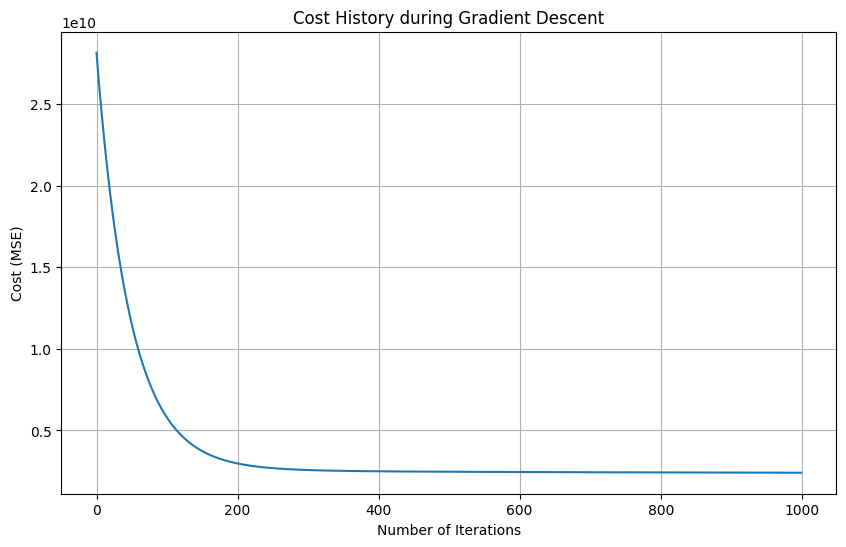

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_np = np_model.predict(X_test_b)

# Evaluate the model
mse_np = mean_squared_error(y_test, y_pred_np)
r2_np = r2_score(y_test, y_pred_np)

print(f"\nMean Squared Error (NumPy): {mse_np:.2f}")
print(f"R-squared (NumPy): {r2_np:.2f}")

# Plotting the cost history
plt.figure(figsize=(10, 6))
plt.plot(np_model.cost_history)
plt.xlabel("Number of Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Cost History during Gradient Descent")
plt.grid(True)
plt.show()

In [ ]:
rmse_np = np.sqrt(mse_np)
print(f"Root Mean Squared Error (NumPy): {rmse_np:.2f}")

Root Mean Squared Error (NumPy): 70533.36


### Visualize Predictions vs. Actual Values

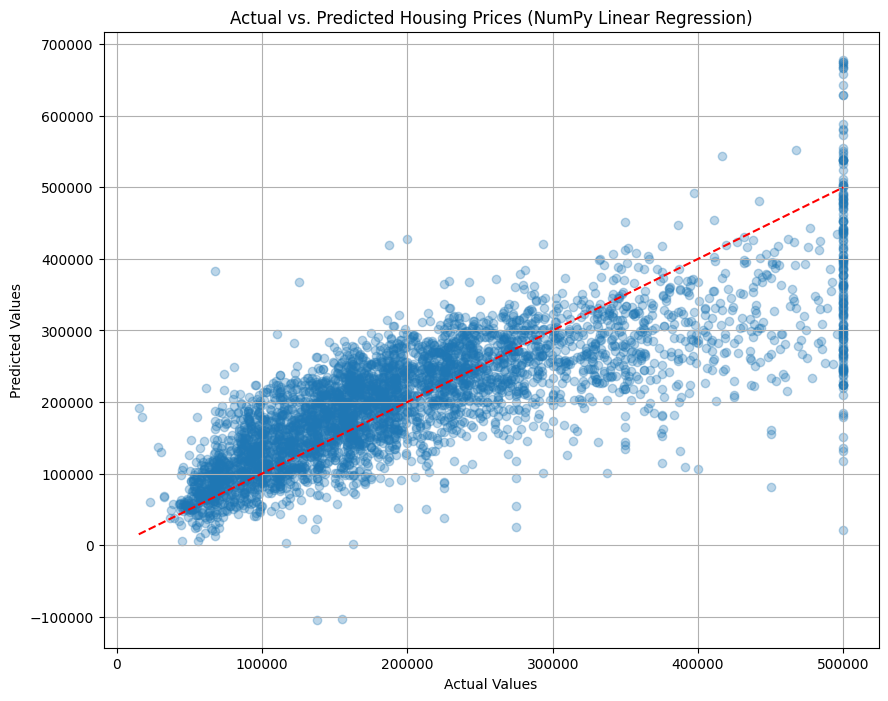

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_np, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Housing Prices (NumPy Linear Regression)")
plt.grid(True)
plt.show()

In [ ]:
print(f"\nMean Squared Error (MSE): {mse_np:.2f}")
print(f"Final Cost after Gradient Descent: {np_model.cost_history[-1]:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_np:.2f}")
print(f"R-squared (R²): {r2_np:.2f}")


Mean Squared Error (MSE): 4974954915.95
Final Cost after Gradient Descent: 2412726171.63
Root Mean Squared Error (RMSE): 70533.36
R-squared (R²): 0.62
